In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv(r'C:\Users\Mahin\Personal-Projects\bdjobs_financial_analyst.csv')

df.drop(columns=['AdType', 'JobTitleBng', 'logo', 'isEarlyAccess', 
                 'OnlineJob', 'JobLang', 'jobContext'], inplace=True)
        

In [16]:
df['degree_level'] = df['degree_level'].str.split(',').apply(lambda x: [i.strip() for i in x] if isinstance(x, list) else x)
df['major'] = df['major'].str.split(',').apply(lambda x: [i.strip() for i in x] if isinstance(x, list) else x)


df_exploded = df.explode('degree_level').explode('major')

major_mapping = {
    'Finance & Banking': 'Finance',
    'Finance and Banking': 'Finance',
    'Accounting & Information System': 'Accounting',
    'Accounting and Information System': 'Accounting',
    # etc.
}
df_exploded['major'] = df_exploded['major'].replace(major_mapping)

In [17]:
df.head()

,Jobid,jobTitle,companyName,deadline,deadlineDB,publishDate,eduRec,degree_level,major,experience,experience_level,location,division
0,1470108,Real Estate Analyst (Data),ZF e Mart,2026-04-23,2026-04-23,2026-03-24,NaN,NaN,NaN,At least 1 years,Entry,DOHS Mirpur,Dhaka
1,1469459,Finance & Accounts Analyst / Specialist,Truvalu.enterprises Limited,2026-03-31,2026-03-31,2026-03-17,"Bachelor’s degree or higher in Accounting, Fin...","[Bachelor, CA, CMA, ACCA]",[Accounting],3 to 5 years,Mid,Dhaka,Dhaka
2,1469244,Management Trainee Officer (MTO) - Junior Analyst,Reazaur Rahman & Associates,2026-04-15,2026-04-15,2026-03-16,Diploma in Computer Bachelor of Business Admin...,"[Diploma, BBA]",NaN,NaN,NaN,Dhaka,Dhaka
3,1465865,Sr. Data Analyst,ASAI Management Services Limited,2026-04-03,2026-04-03,2026-03-04,Bachelor of Science (BSc) in Computer Science ...,[BSc],"[Computer Science, Statistics, Data Science]",3 to 4 years,Mid,Dhaka,Dhaka
4,1467477,Data Analyst,ZTE Corporation,2026-04-09,2026-04-09,2026-03-10,Hold Bachelor or above degree with Computer/Ne...,[Bachelor],NaN,At least 5 years,Mid,Dhaka,Dhaka


In [18]:
df_exploded.head()

,Jobid,jobTitle,companyName,deadline,deadlineDB,publishDate,eduRec,degree_level,major,experience,experience_level,location,division
0,1470108,Real Estate Analyst (Data),ZF e Mart,2026-04-23,2026-04-23,2026-03-24,NaN,NaN,NaN,At least 1 years,Entry,DOHS Mirpur,Dhaka
1,1469459,Finance & Accounts Analyst / Specialist,Truvalu.enterprises Limited,2026-03-31,2026-03-31,2026-03-17,"Bachelor’s degree or higher in Accounting, Fin...",Bachelor,Accounting,3 to 5 years,Mid,Dhaka,Dhaka
1,1469459,Finance & Accounts Analyst / Specialist,Truvalu.enterprises Limited,2026-03-31,2026-03-31,2026-03-17,"Bachelor’s degree or higher in Accounting, Fin...",CA,Accounting,3 to 5 years,Mid,Dhaka,Dhaka
1,1469459,Finance & Accounts Analyst / Specialist,Truvalu.enterprises Limited,2026-03-31,2026-03-31,2026-03-17,"Bachelor’s degree or higher in Accounting, Fin...",CMA,Accounting,3 to 5 years,Mid,Dhaka,Dhaka
1,1469459,Finance & Accounts Analyst / Specialist,Truvalu.enterprises Limited,2026-03-31,2026-03-31,2026-03-17,"Bachelor’s degree or higher in Accounting, Fin...",ACCA,Accounting,3 to 5 years,Mid,Dhaka,Dhaka


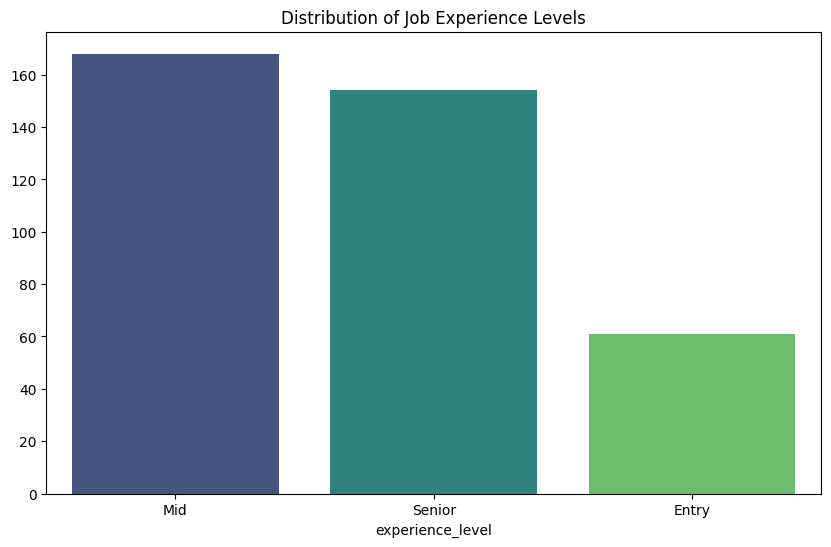

In [19]:
job_experience_counts = df['experience_level'].value_counts()
plt.figure(figsize=(10, 6))
plt.title('Distribution of Job Experience Levels')
sns.barplot(x=job_experience_counts.index, y=job_experience_counts.values, hue=job_experience_counts.index,palette='viridis')
plt.show()

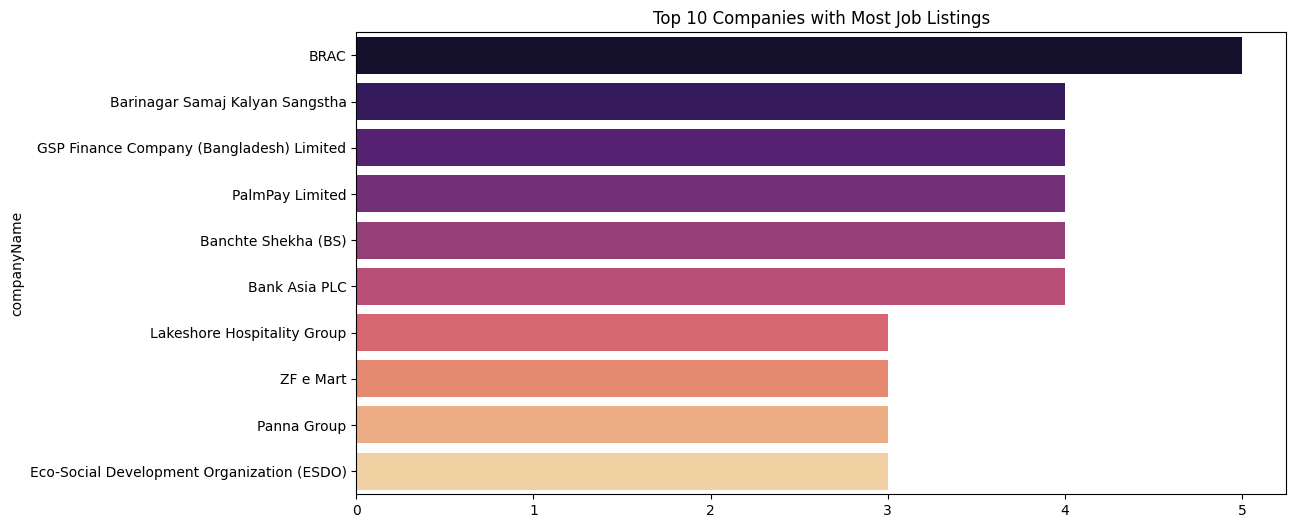

In [20]:
company_counts = df['companyName'].value_counts().head(10)
plt.figure(figsize=(12, 6))
plt.title('Top 10 Companies with Most Job Listings')
sns.barplot(y=company_counts.index, x=company_counts.values, hue=company_counts.index,palette='magma')
plt.show()

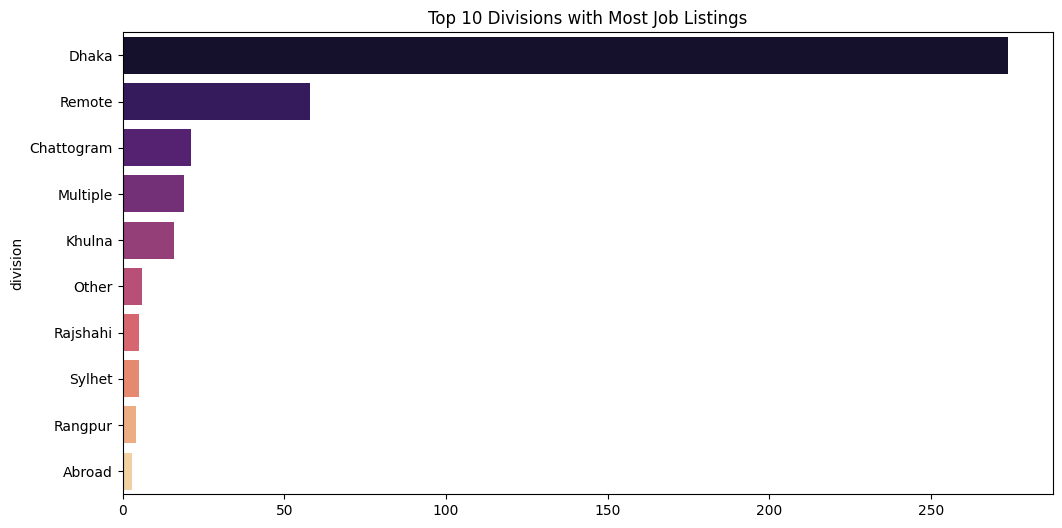

In [21]:
division_counts = df['division'].value_counts().head(10)

plt.figure(figsize=(12, 6))
plt.title('Top 10 Divisions with Most Job Listings')
sns.barplot(y=division_counts.index, x=division_counts.values, hue=division_counts.index,palette='magma')
plt.show()

<Axes: title={'center': 'Top 10 Degree Levels with Most Job Listings'}, ylabel='degree_level'>

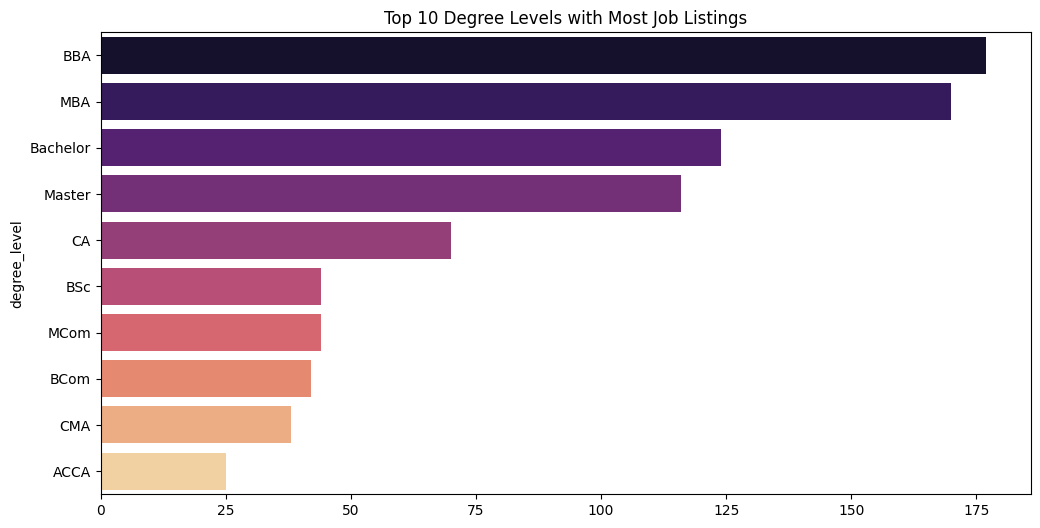

In [22]:
degree_level_counts = df_exploded['degree_level'].value_counts().head(10)
plt.figure(figsize=(12, 6))
plt.title('Top 10 Degree Levels with Most Job Listings')
sns.barplot(y=degree_level_counts.index, x=degree_level_counts.values, hue=degree_level_counts.index,palette='magma')

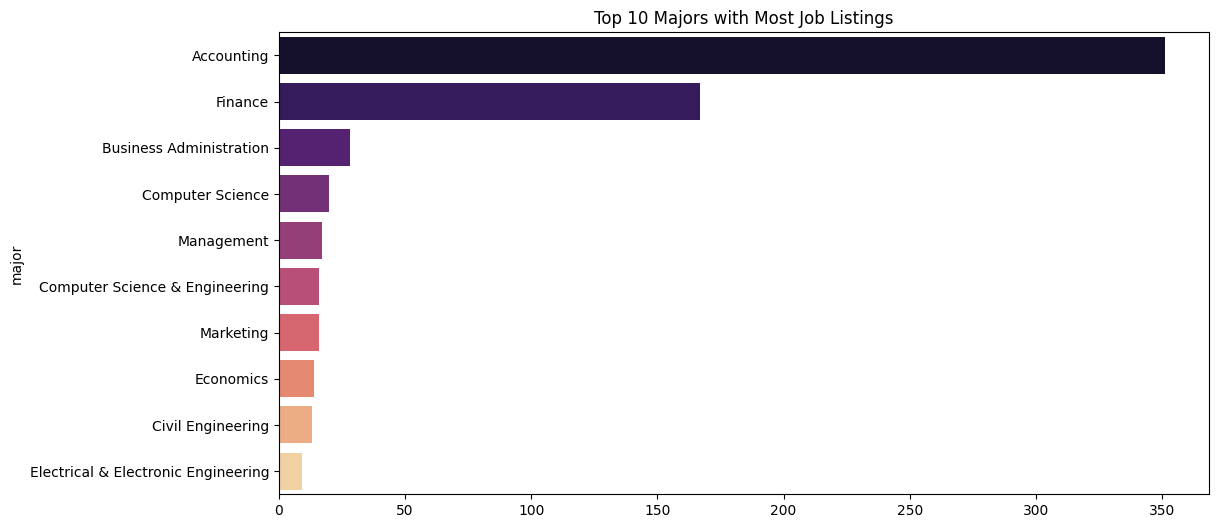

In [23]:
major_counts = df_exploded['major'].value_counts().head(10)
plt.figure(figsize=(12, 6))
plt.title('Top 10 Majors with Most Job Listings')
sns.barplot(y=major_counts.index, x=major_counts.values, hue=major_counts.index,palette='magma')
plt.show()